# OVITO Bond Shell Analysis

This notebook contains comprehensive shell analysis functions for analyzing coordination shells in NaCl-PuCl3 systems using OVITO bond analysis.

## Features:
- Neighbor vs radius analysis for Pu, Na, Cl, and total neighbors
- Automatic shell detection using gradient analysis
- Coordination number distribution analysis
- Shell characteristic comparisons
- High-resolution radius analysis (0.025 Å resolution)

## Usage:
1. Import your data using the bondmodifier_utils
2. Run the shell analysis functions
3. Analyze the results for shell formation patterns


In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import networkx as nx

from cluster_analysis.bond_based.bondmodifier_utils import configure_bonds_modifier_from_cutoffs, build_shared_anion_graph
from cluster_analysis.utils.plots import plot_cluster_size_distribution, analyze_bond_network, plot_rdfs, plot_3d_cluster_with_graph

In [ ]:
from bondmodifier_utils import find_first_minimum
from bondmodifier_utils import gaussian_smooth, _quadratic_refine_minimum
from shell_utils import (
    detect_proper_shells,
    analyze_pu_neighbor_shells,
    plot_shell_diagram,
    analyze_pu_neighbor_distributions,
    plot_coordination_derivatives_2nd_order,
    plot_coordination_with_derivatives
)

In [ ]:
# Function definitions have been moved to shell_utils.py
# Import them using: from shell_utils import detect_proper_shells, ...


In [4]:
# Data loading and setup
import glob

# User inputs - modify these paths as needed
infile = "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.67/T1100K/dump.lammpstrj"
rdf_samples = 100  # adjust for speed/accuracy

# Load data
from bondmodifier_utils import import_file, canonical_cluster_workflow

pipe = import_file(infile, multiple_frames=True)
print(f"Loaded trajectory with {pipe.source.num_frames} frames")

# Run canonical workflow to get initial data
result = canonical_cluster_workflow(
    pipeline=pipe,
    metals=["Pu"],  # Only Pu for cluster analysis
    anion="Cl",
    rdf_samples=rdf_samples,
)

r = result["rdf"]
cutoffs = result["pair_cutoffs"]
names = result["names"]
data0 = result["data"]

print("Pairwise cutoffs:", cutoffs)
print(f"System contains {len(names)} atoms")
print(f"Species: {np.unique(names)}")


Loaded trajectory with 23467 frames
Pairwise cutoffs: {('Pu', 'Cl'): 3.892325560360184, ('Pu', 'Na'): 6.600420038583436, ('Pu', 'Pu'): 6.1737025529157545, ('Cl', 'Pu'): 3.892325560360184, ('Cl', 'Na'): 4.241299056289594, ('Cl', 'Cl'): 4.8192365055429285, ('Na', 'Pu'): 6.600420038583436, ('Na', 'Cl'): 4.241299056289594, ('Na', 'Na'): 6.405466602684178}
System contains 1920 atoms
Species: ['Cl' 'Na' 'Pu']


In [5]:
from bondmodifier_utils import compute_partial_rdfs


In [6]:
rdf=compute_partial_rdfs(pipe, nsamples=100)

In [7]:
from bondmodifier_utils import find_first_shell_minimum

In [8]:
rdf.keys()

dict_keys(['Na-Na', 'Cl-Na', 'Na-Pu', 'Cl-Cl', 'Cl-Pu', 'Pu-Pu', 'r'])

In [9]:
find_first_shell_minimum(r=rdf["r"], g=rdf["Cl-Pu"],min_distance=0.025, max_distance=8.0)

3.8328271139279493

In [10]:
# pipe.modifiers

## Shell Analysis Functions


In [ ]:
# analyze_pu_neighbor_shells function moved to shell_utils.py


In [ ]:
# plot_shell_diagram function moved to shell_utils.py
    

## Usage Examples


PU NEIGHBOR SHELL ANALYSIS
Analyzing 201 radius points for Pu neighbors...


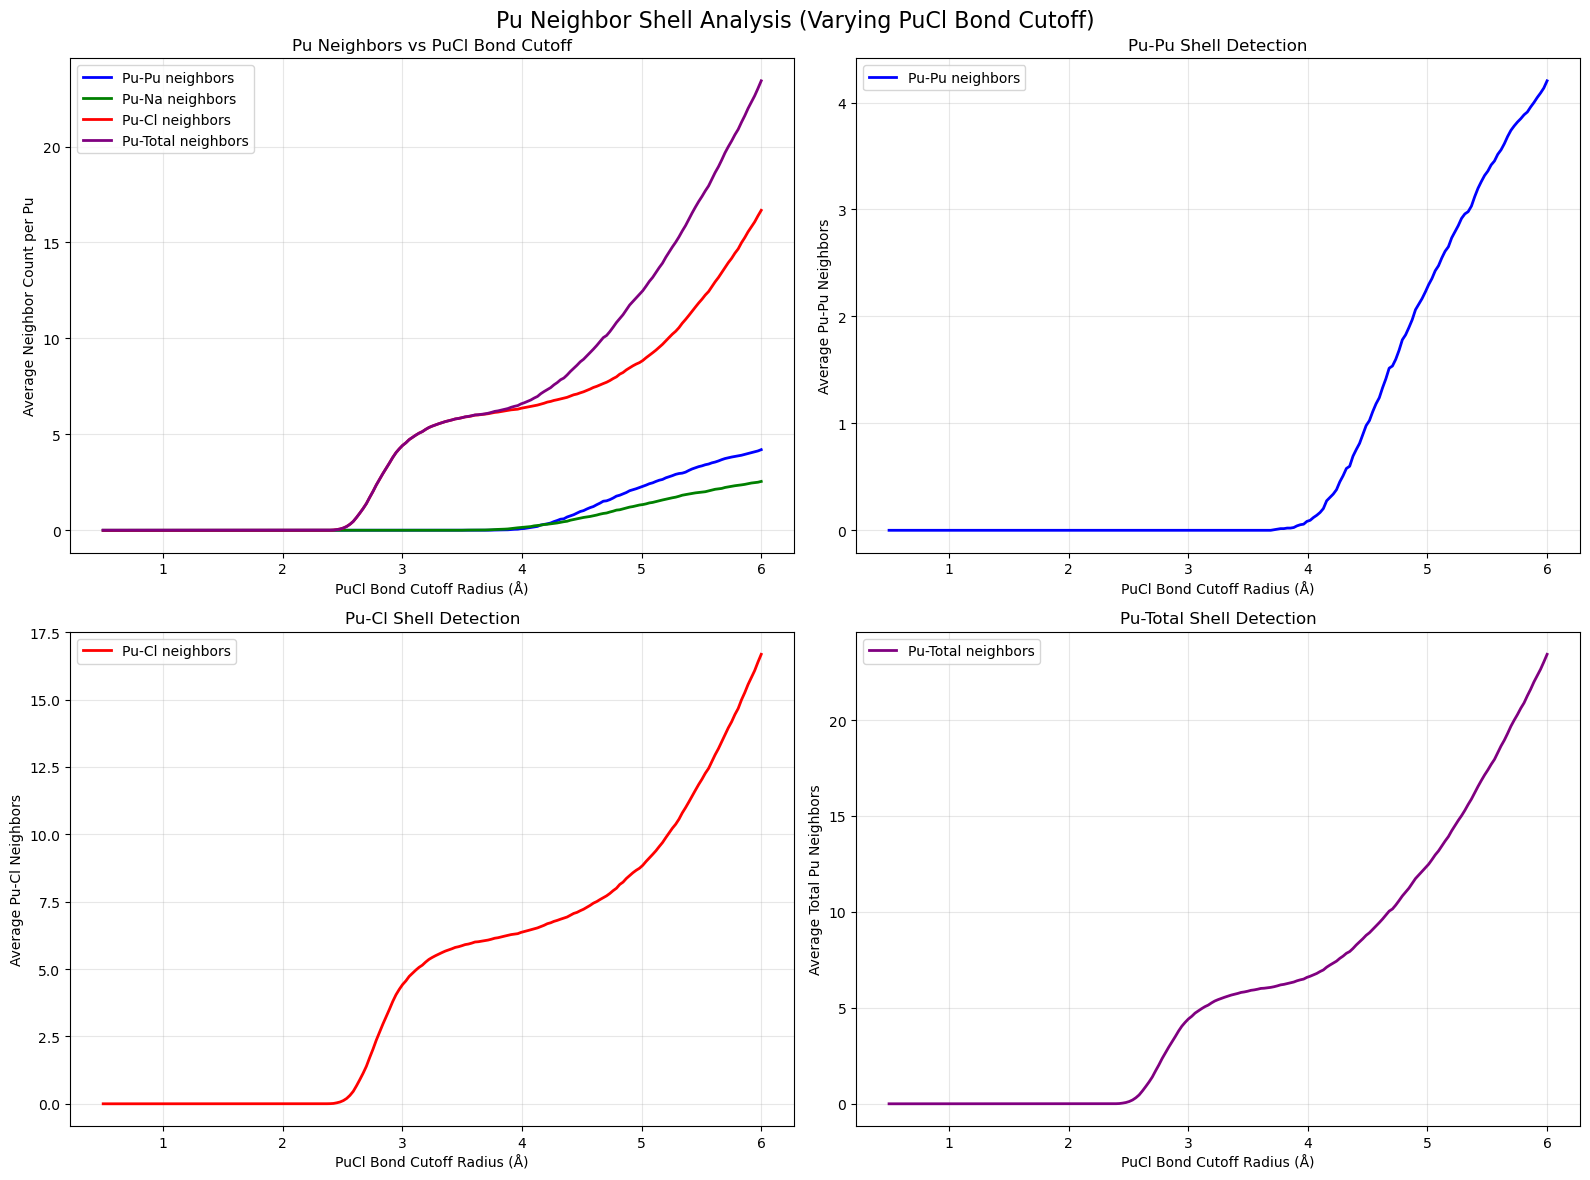


PU NEIGHBOR SHELL ANALYSIS RESULTS:

Pu-Pu Neighbors:
  Max Pu-Pu neighbors: 4.20
  Shells detected: 0

Pu-Na Neighbors:
  Max Pu-Na neighbors: 2.55

Pu-Cl Neighbors:
  Max Pu-Cl neighbors: 16.68
  Shells detected: 0

Pu-Total Neighbors:
  Max Pu-Total neighbors: 23.43
  Shells detected: 0


In [13]:
pu_shell_analysis = analyze_pu_neighbor_shells(pipe, names, cutoffs, max_radius=6.0)
plot_shell_diagram(pu_shell_analysis)

Running Pu neighbor shell analysis...
PU NEIGHBOR SHELL ANALYSIS
Analyzing 201 radius points for Pu neighbors...


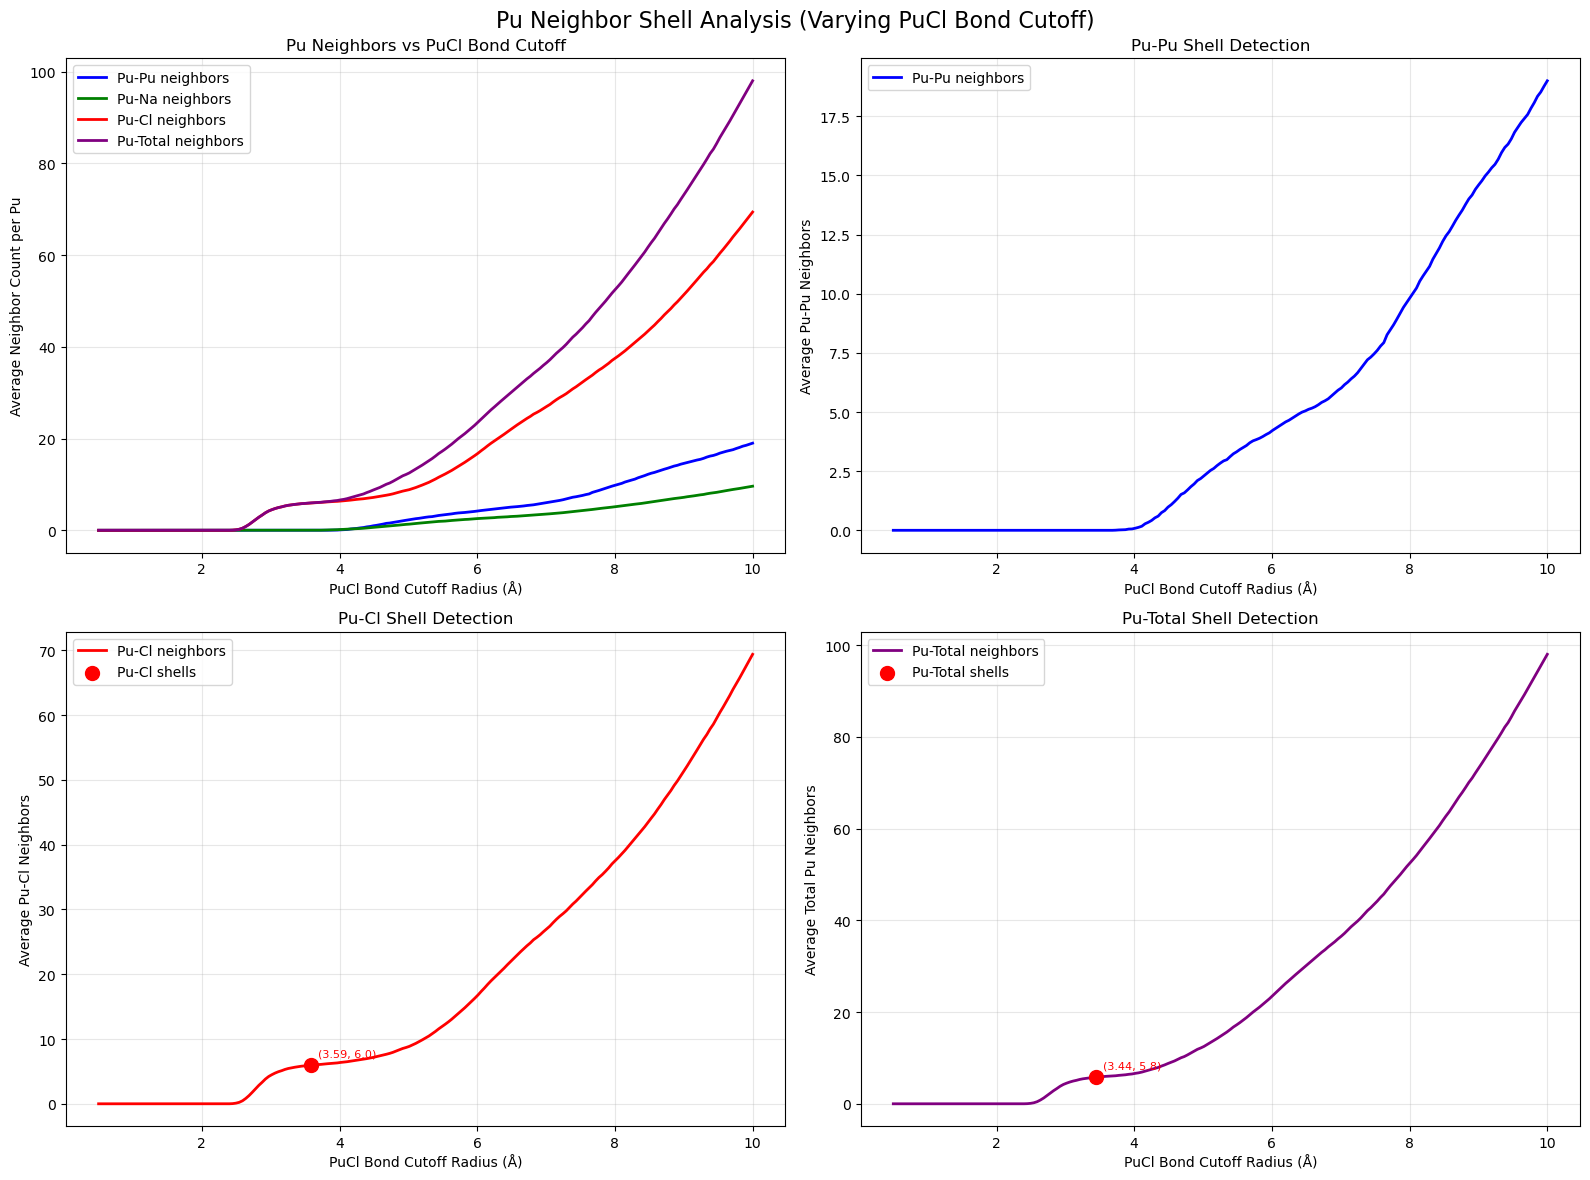


PU NEIGHBOR SHELL ANALYSIS RESULTS:

Pu-Pu Neighbors:
  Max Pu-Pu neighbors: 19.00
  Shells detected: 0

Pu-Na Neighbors:
  Max Pu-Na neighbors: 9.61

Pu-Cl Neighbors:
  Max Pu-Cl neighbors: 69.40
  Shells detected: 1
  Shell radii: ['3.587'] Å

Pu-Total Neighbors:
  Max Pu-Total neighbors: 98.02
  Shells detected: 1
  Shell radii: ['3.445'] Å


In [14]:
# Example 1: Pu neighbor shell analysis (focusing on PuCl bond cutoff)
print("Running Pu neighbor shell analysis...")
pu_shell_analysis = analyze_pu_neighbor_shells(pipe, names, cutoffs, max_radius=10.0)
plot_shell_diagram(pu_shell_analysis)

In [26]:
pu_shell_analysis["radius_range"]

array([ 0.5   ,  0.5475,  0.595 ,  0.6425,  0.69  ,  0.7375,  0.785 ,
        0.8325,  0.88  ,  0.9275,  0.975 ,  1.0225,  1.07  ,  1.1175,
        1.165 ,  1.2125,  1.26  ,  1.3075,  1.355 ,  1.4025,  1.45  ,
        1.4975,  1.545 ,  1.5925,  1.64  ,  1.6875,  1.735 ,  1.7825,
        1.83  ,  1.8775,  1.925 ,  1.9725,  2.02  ,  2.0675,  2.115 ,
        2.1625,  2.21  ,  2.2575,  2.305 ,  2.3525,  2.4   ,  2.4475,
        2.495 ,  2.5425,  2.59  ,  2.6375,  2.685 ,  2.7325,  2.78  ,
        2.8275,  2.875 ,  2.9225,  2.97  ,  3.0175,  3.065 ,  3.1125,
        3.16  ,  3.2075,  3.255 ,  3.3025,  3.35  ,  3.3975,  3.445 ,
        3.4925,  3.54  ,  3.5875,  3.635 ,  3.6825,  3.73  ,  3.7775,
        3.825 ,  3.8725,  3.92  ,  3.9675,  4.015 ,  4.0625,  4.11  ,
        4.1575,  4.205 ,  4.2525,  4.3   ,  4.3475,  4.395 ,  4.4425,
        4.49  ,  4.5375,  4.585 ,  4.6325,  4.68  ,  4.7275,  4.775 ,
        4.8225,  4.87  ,  4.9175,  4.965 ,  5.0125,  5.06  ,  5.1075,
        5.155 ,  5.2


PU NEIGHBOR DISTRIBUTION HISTOGRAMS
Analyzing Pu neighbor distributions at 7 key distances...
  Processing radius 2.0 Å...
  Processing radius 3.0 Å...
  Processing radius 4.0 Å...
  Processing radius 5.0 Å...
  Processing radius 6.0 Å...
  Processing radius 8.0 Å...
  Processing radius 10.0 Å...


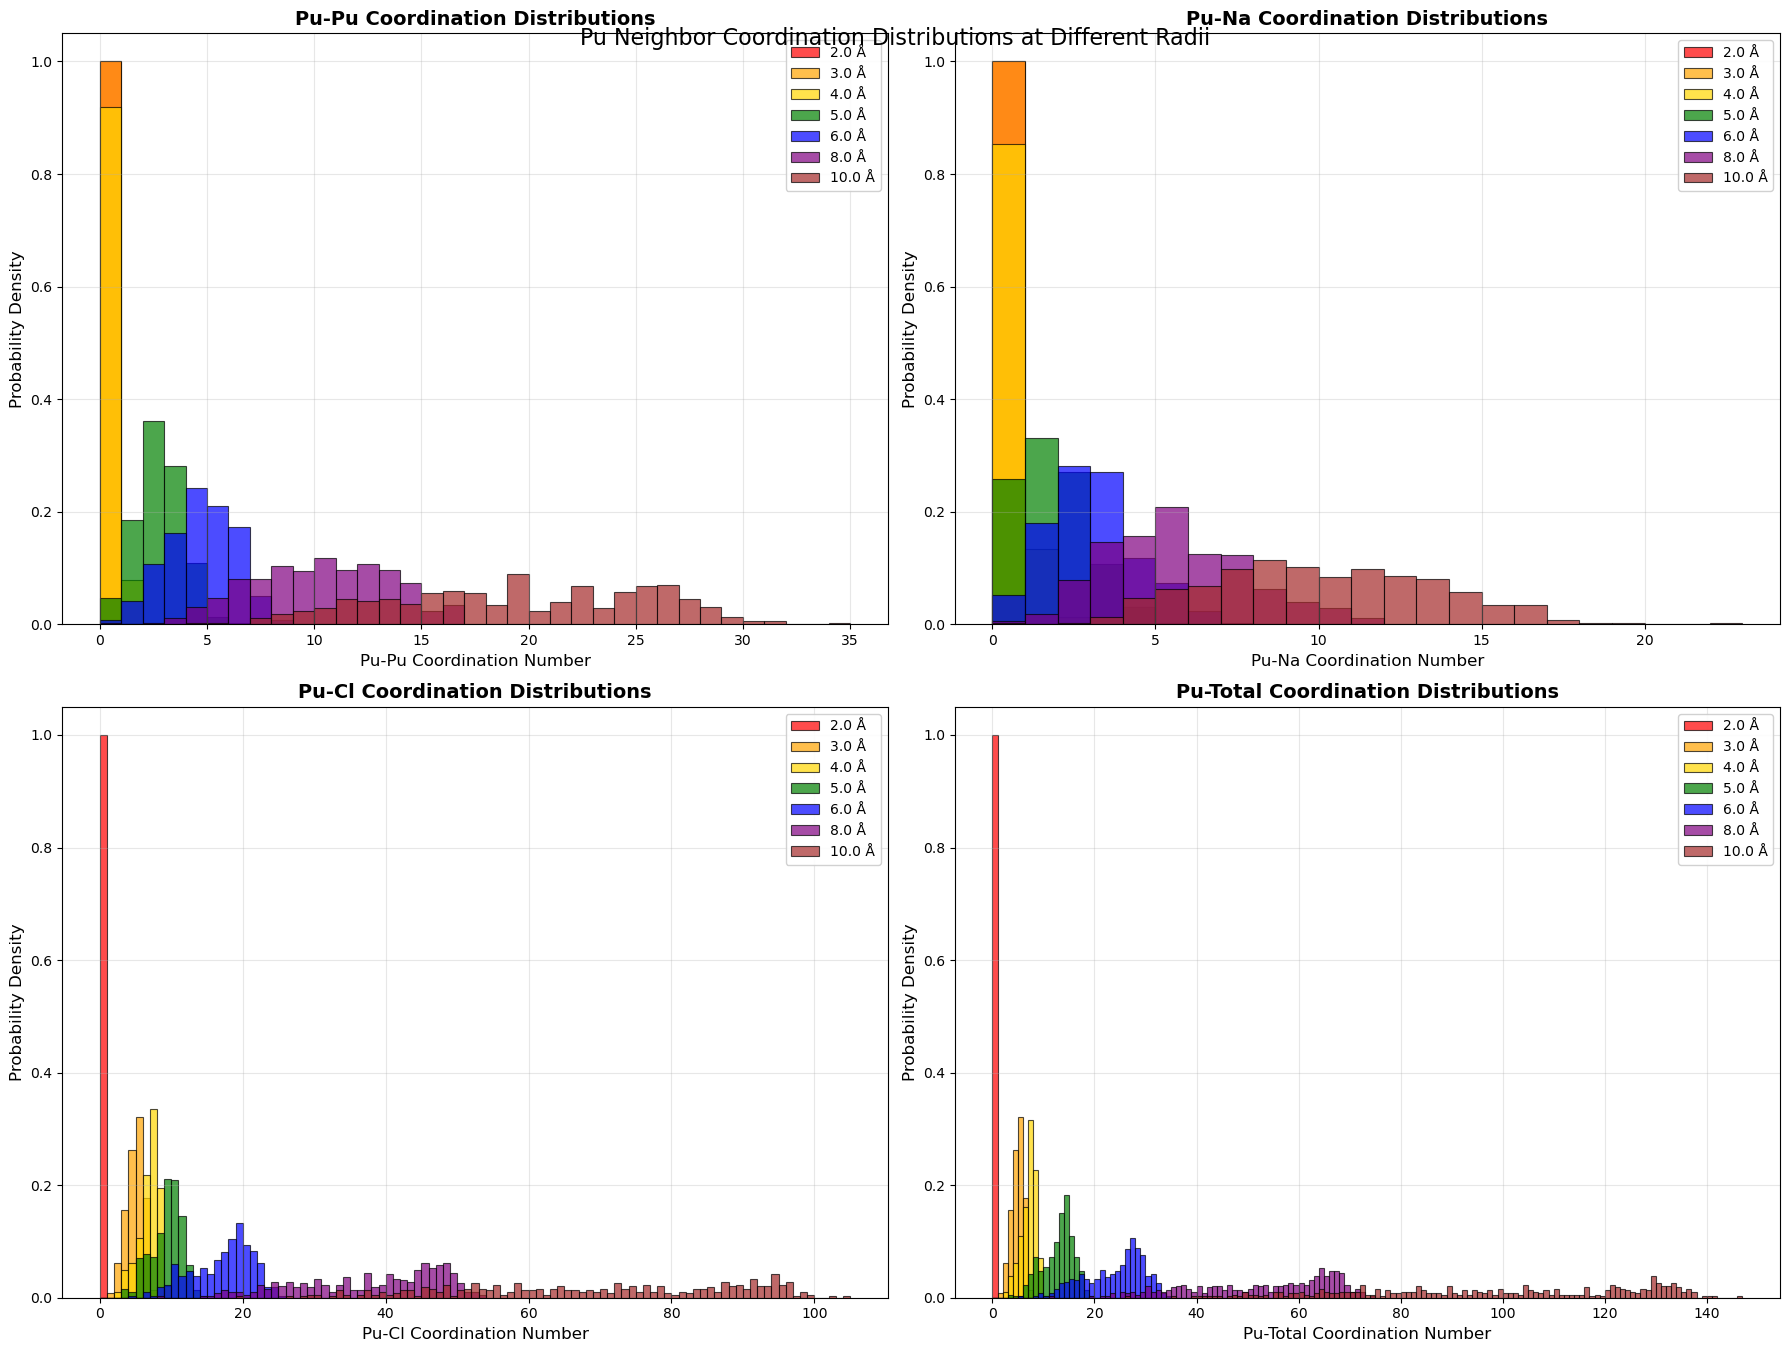

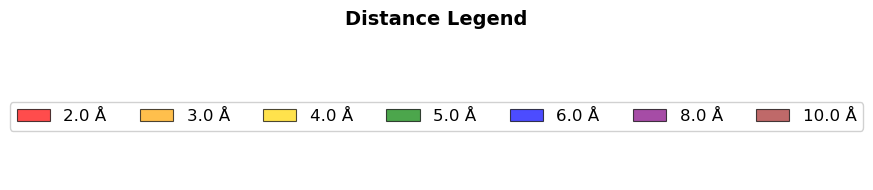


PU NEIGHBOR DISTRIBUTION STATISTICS:

At 2.0 Å:
  Pu-Pu: mean=0.00, std=0.00, range=0-0
  Pu-Na: mean=0.00, std=0.00, range=0-0
  Pu-Cl: mean=0.00, std=0.00, range=0-0
  Total: mean=0.00, std=0.00, range=0-0

At 3.0 Å:
  Pu-Pu: mean=0.00, std=0.00, range=0-0
  Pu-Na: mean=0.00, std=0.00, range=0-0
  Pu-Cl: mean=4.41, std=1.21, range=1-7
  Total: mean=4.41, std=1.21, range=1-7

At 4.0 Å:
  Pu-Pu: mean=0.08, std=0.29, range=0-2
  Pu-Na: mean=0.16, std=0.40, range=0-2
  Pu-Cl: mean=6.37, std=1.46, range=2-9
  Total: mean=6.61, std=1.57, range=2-11

At 5.0 Å:
  Pu-Pu: mean=2.27, std=1.08, range=0-6
  Pu-Na: mean=1.33, std=1.08, range=0-5
  Pu-Cl: mean=8.82, std=2.15, range=3-14
  Total: mean=12.42, std=3.02, range=3-19

At 6.0 Å:
  Pu-Pu: mean=4.20, std=1.59, range=0-8
  Pu-Na: mean=2.55, std=1.39, range=0-7
  Pu-Cl: mean=16.68, std=4.21, range=4-25
  Total: mean=23.43, std=5.80, range=5-34

At 8.0 Å:
  Pu-Pu: mean=9.80, std=3.18, range=0-16
  Pu-Na: mean=5.14, std=2.18, range=0-11
  Pu-C

In [16]:
# analyze_pu_neighbor_distributions and related functions moved to shell_utils.py

# Run the Pu neighbor distribution analysis
pu_dist_analysis = analyze_pu_neighbor_distributions(pipe, names, cutoffs, max_radius=10.0)


COORDINATION DERIVATIVES ANALYSIS


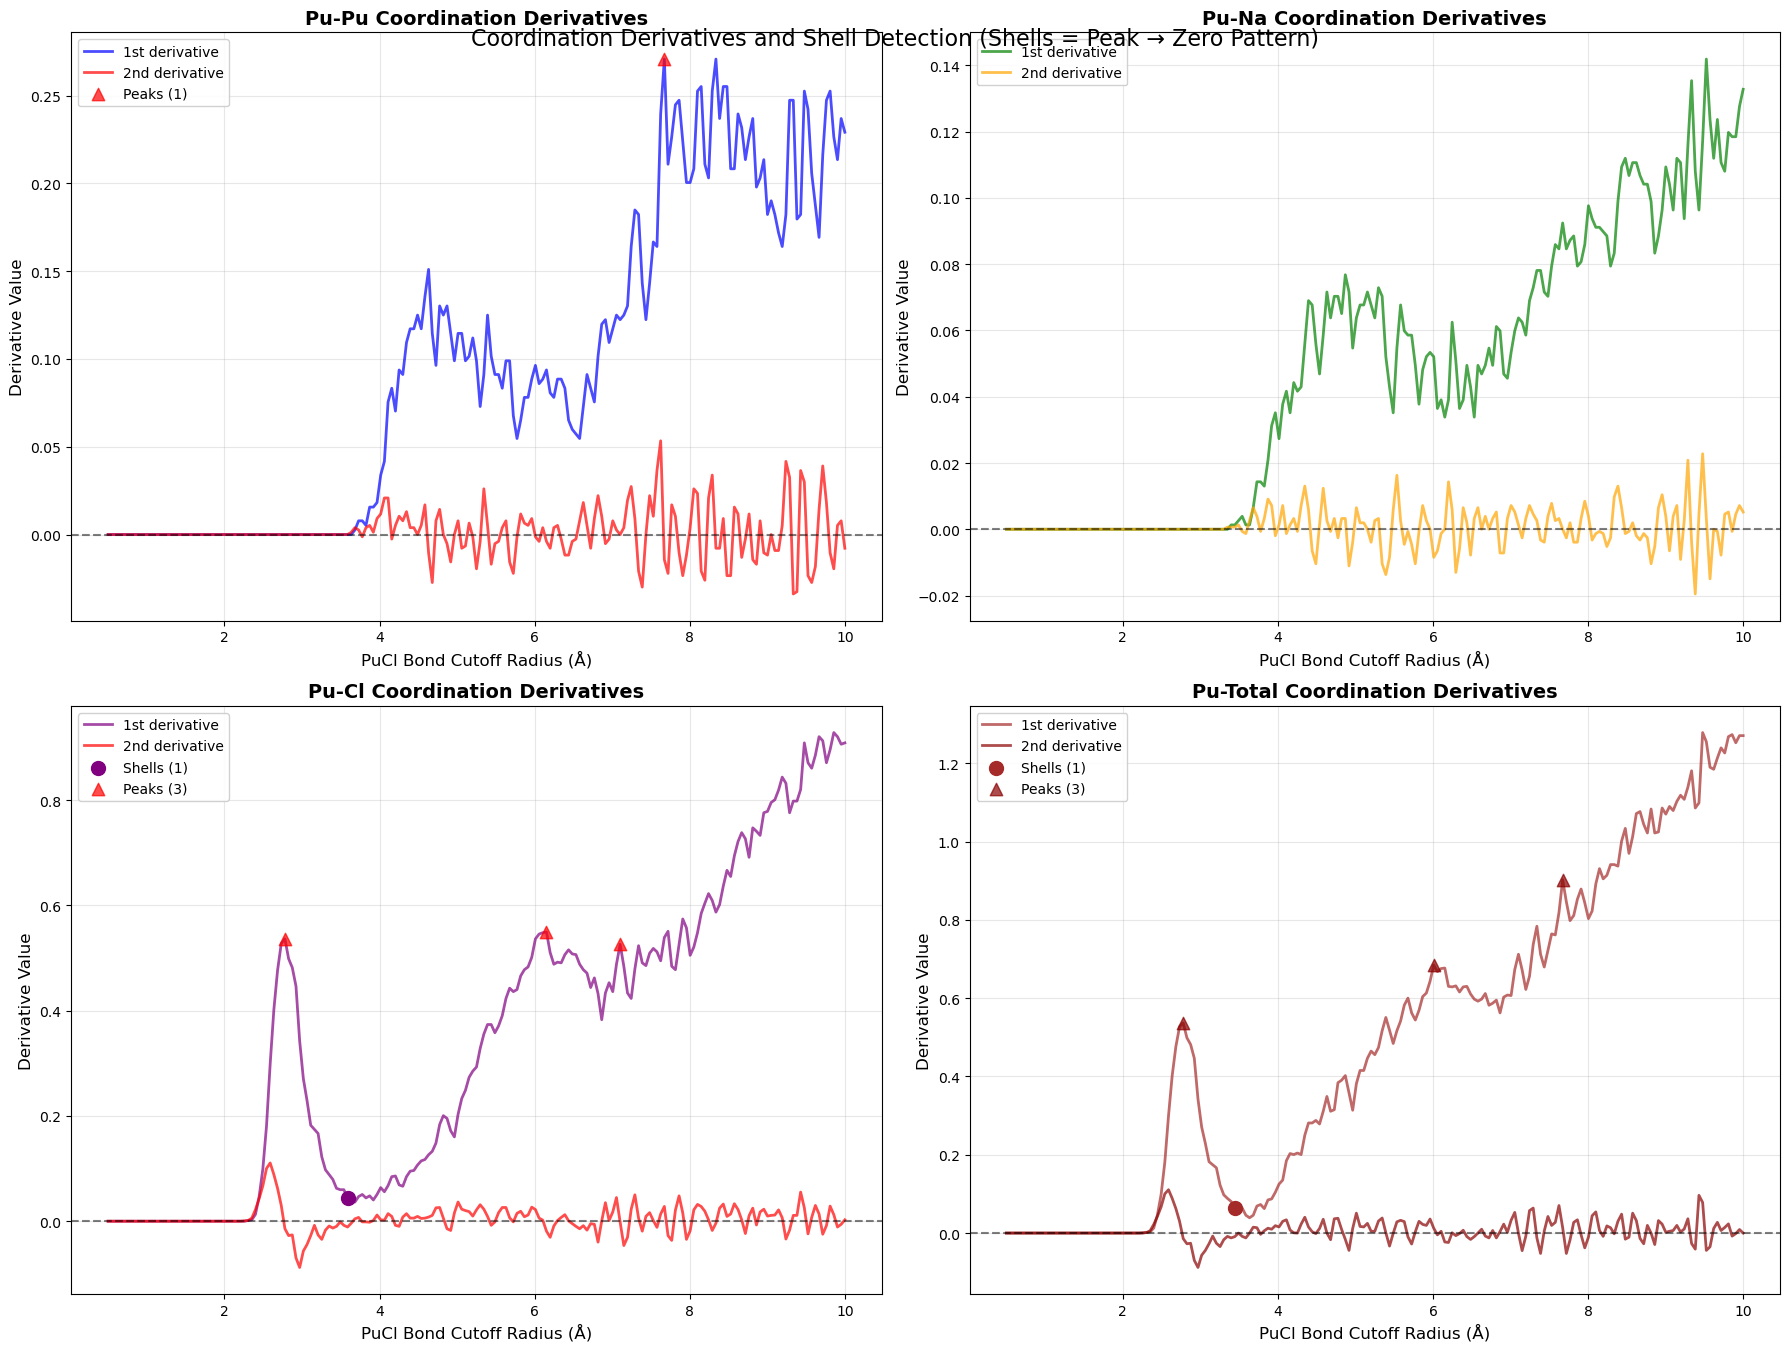


PROPER SHELL DETECTION ANALYSIS:

Pu-Pu Coordination:
  Derivative peaks found: 1
  Shell boundaries detected: 0
  Peak radii: ['7.673'] Å

Pu-Na Coordination:
  Derivative peaks found: 0
  Shell boundaries detected: 0

Pu-Cl Coordination:
  Derivative peaks found: 3
  Shell boundaries detected: 1
  Peak radii: ['2.780', '6.152', '7.103'] Å
  Shell radii: ['3.587'] Å

Pu-Total Coordination:
  Derivative peaks found: 3
  Shell boundaries detected: 1
  Peak radii: ['2.780', '6.010', '7.673'] Å
  Shell radii: ['3.445'] Å


In [19]:
# plot_coordination_derivatives_2nd_order function moved to shell_utils.py

# Run the derivatives analysis
derivatives_analysis = plot_coordination_derivatives_2nd_order(pu_shell_analysis)


COORDINATION WITH FIRST DERIVATIVE OVERLAY


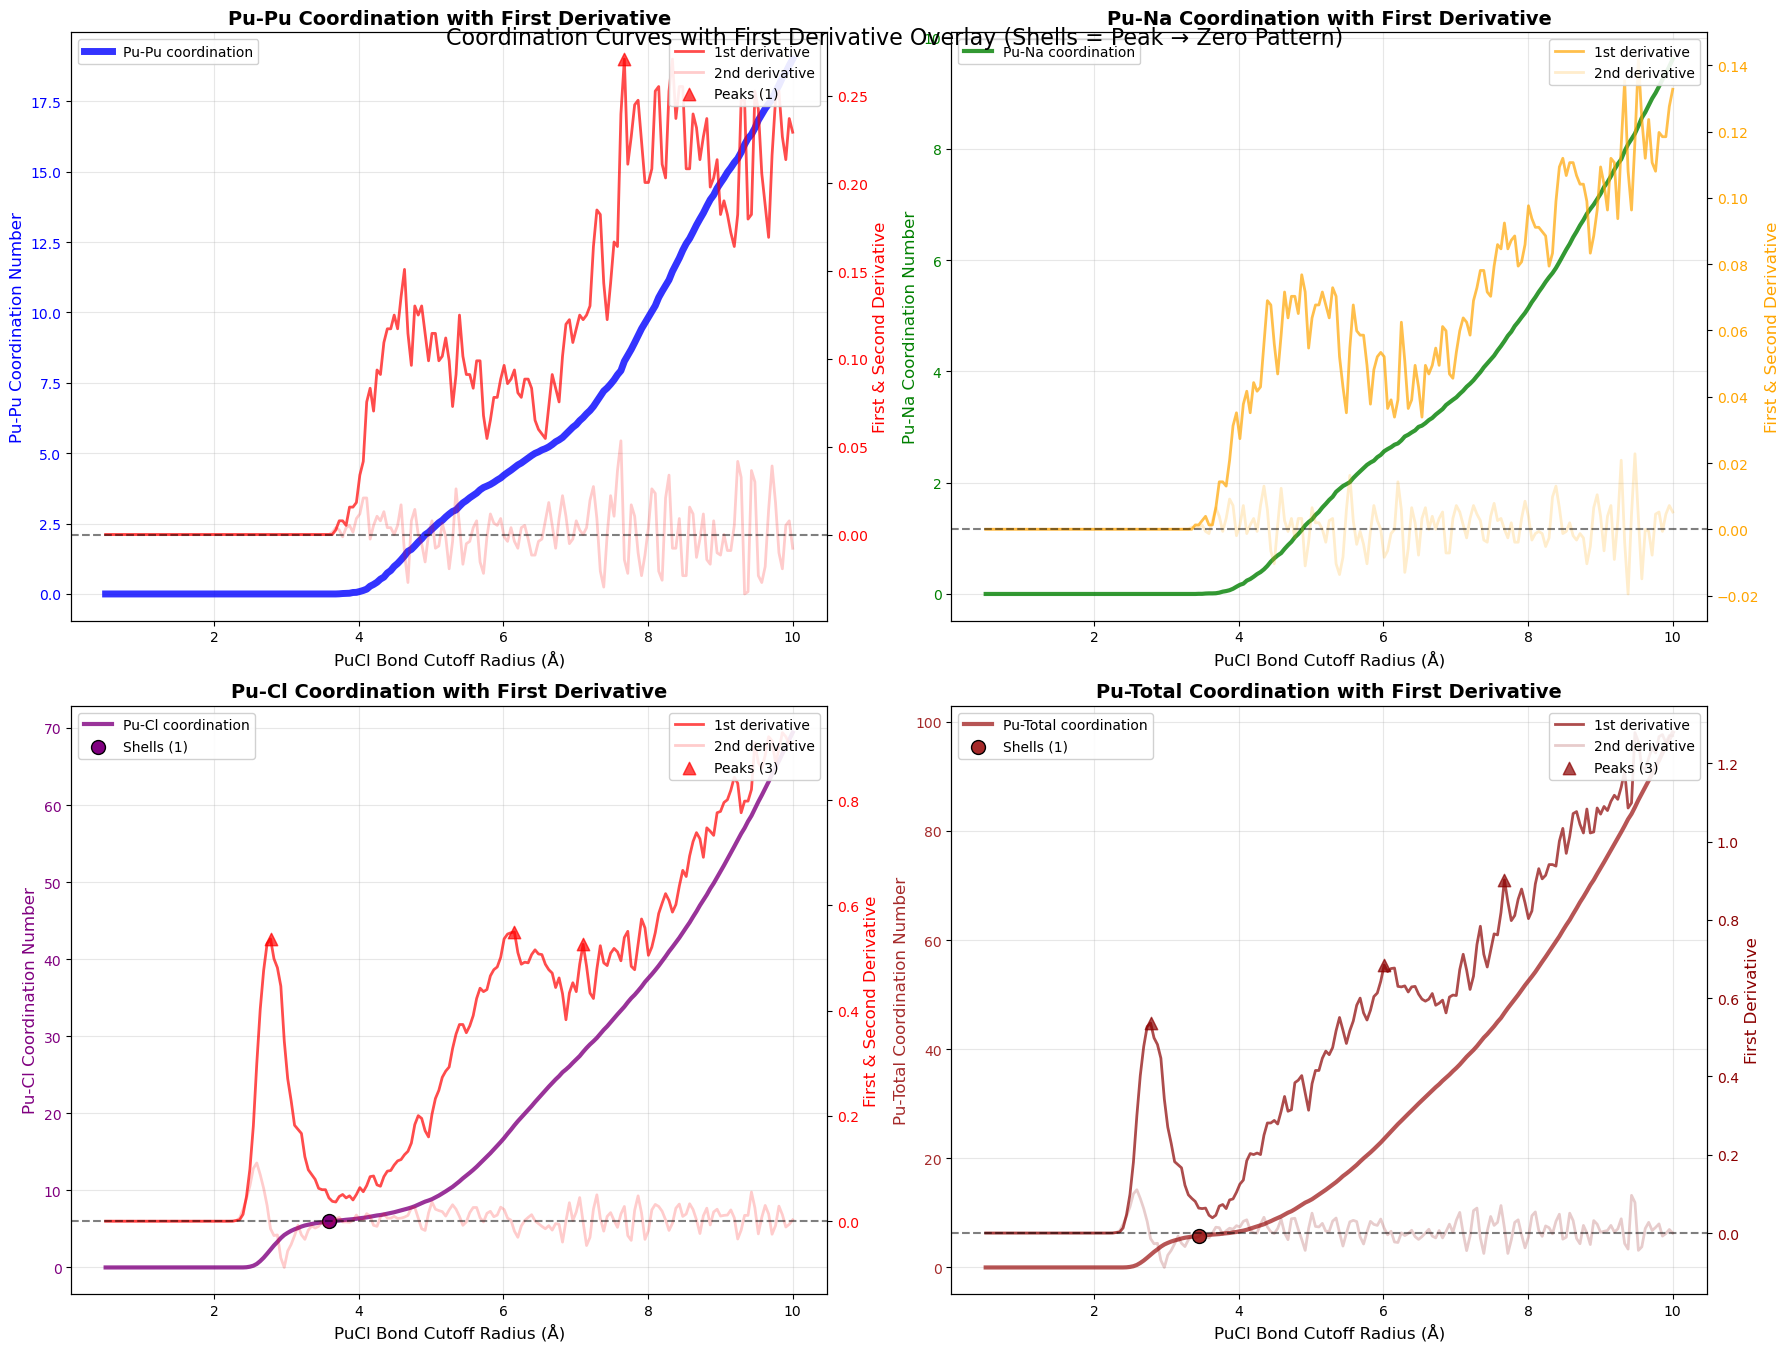


PROPER SHELL BOUNDARY ANALYSIS:

Pu-Pu Coordination:
  Derivative peaks found: 1
  Shell boundaries detected: 0
  Peak radii: ['7.673'] Å

Pu-Na Coordination:
  Derivative peaks found: 0
  Shell boundaries detected: 0

Pu-Cl Coordination:
  Derivative peaks found: 3
  Shell boundaries detected: 1
  Peak radii: ['2.780', '6.152', '7.103'] Å
  Shell radii: ['3.587'] Å
  Coordination at shells: ['6.0']

Pu-Total Coordination:
  Derivative peaks found: 3
  Shell boundaries detected: 1
  Peak radii: ['2.780', '6.010', '7.673'] Å
  Shell radii: ['3.445'] Å
  Coordination at shells: ['5.8']


In [18]:
# plot_coordination_with_derivatives function moved to shell_utils.py

# Run the coordination with derivatives overlay analysis
coordination_derivatives_overlay = plot_coordination_with_derivatives(pu_shell_analysis)